# 03 — Exploratory Data Analysis

**Stage 3 of the Tier A pipeline** · input `data/processed/boston_clean.parquet`

> **EDA here is hypothesis-driven, not open-ended.** Every section below maps to one branch of the
> MECE issue tree from Stage 0, and every chart maps to a slide in the ghost deck. STRUCTURE.md is
> blunt about the alternative: *"30+ charts with no narrative thread."*

**The issue tree being tested**

| Branch | Hypothesis | Features |
|---|---|---|
| **A. Structural** | Bigger, newer housing stock commands higher value | `RM`, `AGE`, `ZN` |
| **B. Socioeconomic** | Neighbourhood composition dominates everything else | `LSTAT`, `CRIM`, `PTRATIO` |
| **C. Environmental** | Pollution and industry depress value | `NOX`, `INDUS`, `CHAS` |
| **D. Location / fiscal** | Access and tax burden shape value | `DIS`, `RAD`, `TAX` |

Four branches, 13 features, each assigned exactly once — no overlaps, no gaps.

Every exhibit carries an **action title** stating the insight and a written **So What / Implication**.
A chart without a written insight is decoration, not analysis.

In [1]:
from __future__ import annotations

import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

PROJECT = Path.cwd().parent
PROC = PROJECT / "data" / "processed"
FIGS = PROJECT / "reports" / "figures"
FIGS.mkdir(parents=True, exist_ok=True)

pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 30)

In [2]:
# --- McKinsey chart style (DOCS/DESIGN.md) -------------------------------------
# Defined inline, not imported: only notebooks/, reports/final_report.html and README.md
# ship to GitHub, so importing a local src/ module would make this notebook unrunnable
# for anyone who clones the repo.
#
# PALETTE VALIDATION (dataviz validator, 2026-07-20)
#   DESIGN.md claims the 5-slot order passes with worst adjacent dE=60.7. It does not:
#     node scripts/validate_palette.js "#2251FF,#00857C,#C1841C,#00A9F4,#7F93A6" --mode light
#     [FAIL] Normal-vision floor  #7F93A6 <-> #00A9F4  dE 12.9  (hard floor 15)
#   Cyan and Slate are not separable as adjacent series even with full colour vision.
#   Resolution: CATEGORICAL is capped at THREE slots (Blue -> Teal -> Amber), which PASSES
#   every separation check (worst dE 13.2 protan / 21.8 normal, contrast >= 3:1). Cyan is
#   demoted to non-adjacent use; Slate and Grey are chrome (labels, context), never series.
#   This project never needs more than 3 simultaneous series, so the cap costs nothing.

import matplotlib as mpl
import matplotlib.pyplot as plt

NAVY     = "#051C2C"   # ink and dark ground -- NEVER a series fill
BLUE     = "#2251FF"   # emphasis / the insight
TEAL     = "#00857C"   # comparison series
CYAN     = "#00A9F4"   # tertiary, non-adjacent only
AMBER    = "#C1841C"   # reference lines, thresholds, censoring markers
SLATE    = "#7F93A6"   # muted labels
GREY     = "#9FADB8"   # neutral context
GRIDLINE = "#E9ECEF"
WHITE    = "#FFFFFF"

CATEGORICAL = [BLUE, TEAL, AMBER]          # fixed order, never cycled
EMPHASIS, COMPARE, CONTEXT, REFERENCE = BLUE, TEAL, GREY, AMBER
SEQUENTIAL = ["#E8EDFF", "#B8C7FF", "#7B96FF", "#4A6EFF", BLUE, "#0A2FB8"]
DIVERGING  = ["#8A3A12", "#C1841C", "#E4E7EA", "#4A6EFF", "#0A2FB8"]

def apply_style():
    plt.rcdefaults()
    mpl.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica Neue", "DejaVu Sans"],
        "font.size": 10,
        "axes.titlelocation": "left",      # action titles sit flush-left
        "axes.titlesize": 12, "axes.titleweight": "bold",
        "axes.titlecolor": NAVY, "axes.titlepad": 12,
        "text.color": NAVY, "axes.labelcolor": NAVY, "axes.labelsize": 10,
        "xtick.color": SLATE, "ytick.color": SLATE,
        "xtick.labelcolor": NAVY, "ytick.labelcolor": NAVY,
        "axes.spines.top": False, "axes.spines.right": False,
        "axes.edgecolor": SLATE, "axes.linewidth": 0.8,
        "xtick.major.width": 0.8, "ytick.major.width": 0.8,
        "axes.grid": True, "axes.axisbelow": True,
        "grid.color": GRIDLINE, "grid.linewidth": 0.8,
        "figure.facecolor": WHITE, "axes.facecolor": WHITE,
        "savefig.facecolor": WHITE, "savefig.bbox": "tight",
        "savefig.dpi": 160, "figure.dpi": 110, "figure.figsize": (8.0, 4.8),
        "lines.linewidth": 2.0, "lines.markersize": 8,
        "legend.frameon": False, "legend.fontsize": 9,
        "axes.prop_cycle": mpl.cycler(color=CATEGORICAL),
    })

def action_title(ax, title, subtitle=None):
    """Title states the INSIGHT, not the content (STRUCTURE.md pillar 5)."""
    ax.set_title(title, loc="left", pad=20 if subtitle else 12)
    if subtitle:
        ax.text(0.0, 1.02, subtitle, transform=ax.transAxes,
                fontsize=9, color=SLATE, va="bottom", ha="left")

def source_note(fig, text):
    """Source + caveat footnote required on every Tier A exhibit."""
    fig.text(0.0, -0.03, text, fontsize=8, color=SLATE, ha="left", va="top")

SOURCE = ("Source: Boston Housing (Harrison & Rubinfeld 1978), UCI ML Repository. "
          "506 census tracts, Boston SMSA, 1970. MEDV top-coded at $50k (16 tracts).")

apply_style()
print("chart style applied - categorical capped at 3 validated slots")


chart style applied - categorical capped at 3 validated slots


In [3]:
# The dtype contract parquet cannot carry (see 02_cleaning ss2.6).
def apply_dtype_contract(frame, contract):
    frame = frame.copy()
    for col, cats in contract["ordered_categorical"].items():
        frame[col] = pd.Categorical(frame[col].astype(int), categories=cats, ordered=True)
    for col in contract["int8"]:
        frame[col] = frame[col].astype("int8")
    for col in contract["float64"]:
        frame[col] = frame[col].astype("float64")
    return frame

CONTRACT = json.loads((PROC / "_dtype_contract.json").read_text())
df = apply_dtype_contract(pd.read_parquet(PROC / "boston_clean.parquet"), CONTRACT)

CONTINUOUS = ["CRIM", "ZN", "INDUS", "NOX", "RM", "AGE", "DIS",
              "TAX", "PTRATIO", "LSTAT"]          # model-eligible continuous features
EXCLUDED   = ["B"]                                 # race-derived, barred from models
TARGET     = "MEDV"

print(f"loaded {df.shape[0]} tracts x {df.shape[1]} columns")
print(f"RAD dtype restored: {df['RAD'].dtype} (ordered={df['RAD'].cat.ordered})")
print(f"censored tracts: {int(df.is_MEDV_censored.sum())}")


loaded 506 tracts x 15 columns
RAD dtype restored: category (ordered=True)
censored tracts: 16


## 3.1 First-pass profile

`ydata-profiling` is the tool STRUCTURE.md nominates, but it does not currently support
`pandas 3.x`, so installing it would break the pinned environment. The equivalent summary is
computed directly — the point of the automated profile is the *information*, not the package.

In [4]:
prof = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_unique": df.nunique(),
    "n_missing": df.isna().sum(),
    "mean": df.select_dtypes("number").mean().round(2),
    "std": df.select_dtypes("number").std().round(2),
    "min": df.select_dtypes("number").min().round(2),
    "median": df.select_dtypes("number").median().round(2),
    "max": df.select_dtypes("number").max().round(2),
    "skew": df.select_dtypes("number").skew().round(2),
})
print(f"{df.shape[0]} tracts x {df.shape[1]} columns | missing cells: {int(df.isna().sum().sum())}")
prof

506 tracts x 15 columns | missing cells: 0


,dtype,n_unique,n_missing,mean,std,min,median,max,skew
AGE,float64,356,0,68.57,28.15,2.90,77.50,100.00,-0.60
B,float64,357,0,356.67,91.29,0.32,391.44,396.90,-2.89
CHAS,int8,2,0,0.07,0.25,0.00,0.00,1.00,3.41
CRIM,float64,504,0,3.61,8.60,0.01,0.26,88.98,5.22
DIS,float64,412,0,3.80,2.11,1.13,3.21,12.13,1.01
INDUS,float64,76,0,11.14,6.86,0.46,9.69,27.74,0.30
LSTAT,float64,455,0,12.65,7.14,1.73,11.36,37.97,0.91
MEDV,float64,229,0,22.53,9.20,5.00,21.20,50.00,1.11
NOX,float64,81,0,0.55,0.12,0.38,0.54,0.87,0.73
PTRATIO,float64,46,0,18.46,2.16,12.60,19.05,22.00,-0.80


> **So What:** three features are severely right-skewed (`CRIM` 5.2, `ZN` 2.2, `B` −2.9), which
> will violate the normality assumptions of parametric tests and destabilise linear coefficients.
> **Implication:** log transforms are required at Stage 4 for `CRIM` and `DIS` — flagged now, applied
> there, never by deleting rows.

## 3.2 Branch A+B — Two features carry almost all the signal

The correlation matrix is the fastest MECE sweep across all four branches at once.

In [5]:
num = df[CONTINUOUS + EXCLUDED + ["CHAS", TARGET]]
corr = num.corr(numeric_only=True)

target_corr = (
    corr[TARGET].drop(TARGET)
    .to_frame("pearson_r")
    .assign(abs_r=lambda d: d.pearson_r.abs())
    .sort_values("abs_r", ascending=False)
    .round(3)
)
# Spearman picks up monotone-but-curved relationships that Pearson understates.
target_corr["spearman_rho"] = [
    round(stats.spearmanr(df[c], df[TARGET]).statistic, 3) for c in target_corr.index
]
target_corr["gap_signals_curvature"] = (
    (target_corr.spearman_rho.abs() - target_corr.pearson_r.abs()).round(3)
)
target_corr[["pearson_r", "spearman_rho", "gap_signals_curvature"]]

,pearson_r,spearman_rho,gap_signals_curvature
LSTAT,-0.738,-0.853,0.115
RM,0.695,0.634,-0.061
PTRATIO,-0.508,-0.556,0.048
INDUS,-0.484,-0.578,0.094
TAX,-0.469,-0.562,0.093
NOX,-0.427,-0.563,0.136
CRIM,-0.388,-0.559,0.171
AGE,-0.377,-0.548,0.171
ZN,0.360,0.438,0.078
B,0.333,0.186,-0.147


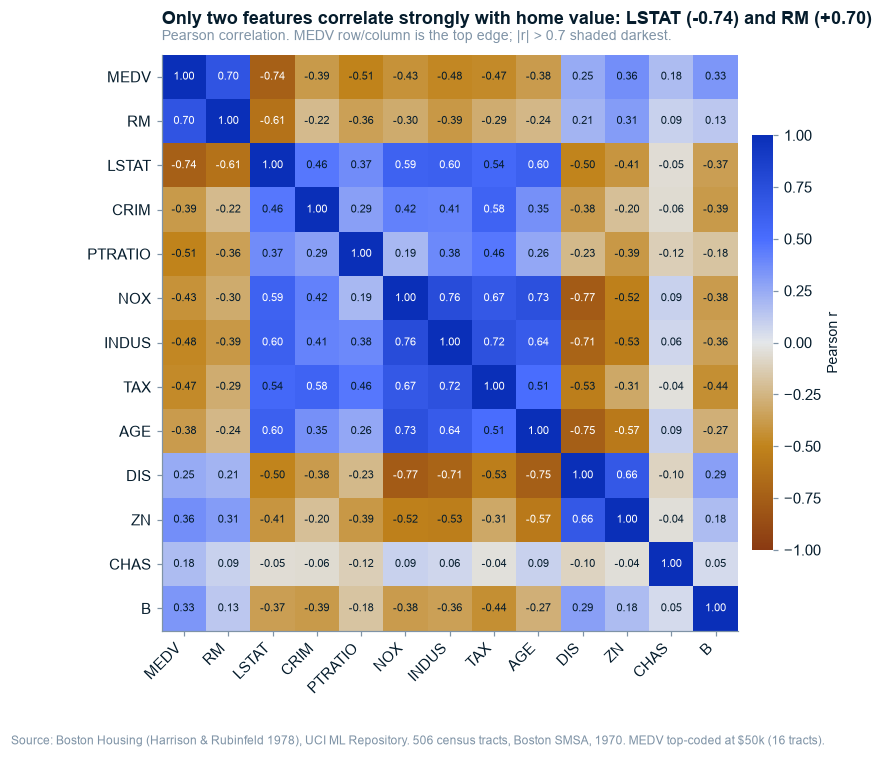

In [6]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Diverging map: two hues either side of a NEUTRAL grey midpoint (never a hue at zero).
cmap = LinearSegmentedColormap.from_list("mck_div", DIVERGING, N=256)

order = [TARGET, "RM", "LSTAT", "CRIM", "PTRATIO", "NOX", "INDUS", "TAX", "AGE", "DIS", "ZN", "CHAS", "B"]
c = df[order].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(8.6, 6.8))
im = ax.imshow(c, cmap=cmap, vmin=-1, vmax=1)

ax.set_xticks(range(len(order)), order, rotation=45, ha="right")
ax.set_yticks(range(len(order)), order)
ax.grid(False)

# Direct labels = the secondary encoding, so identity never rests on colour alone.
for i in range(len(order)):
    for j in range(len(order)):
        v = c.iloc[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7,
                color=WHITE if abs(v) > 0.55 else NAVY)

action_title(ax,
    "Only two features correlate strongly with home value: LSTAT (-0.74) and RM (+0.70)",
    "Pearson correlation. MEDV row/column is the top edge; |r| > 0.7 shaded darkest.")
cb = fig.colorbar(im, ax=ax, shrink=0.72, pad=0.02)
cb.set_label("Pearson r", color=NAVY, fontsize=9)
cb.outline.set_visible(False)
source_note(fig, SOURCE)
fig.savefig(FIGS / "ex01_correlation.png", facecolor=WHITE, bbox_inches="tight", dpi=160)
plt.show()

> **So What:** of 13 candidate features, exactly two clear |r| > 0.65 — `LSTAT` (−0.74) and `RM`
> (+0.70). Branch B (socioeconomic) and Branch A (structural) dominate; Branches C and D show only
> moderate correlations that may be inherited rather than independent.
>
> **Implication:** the investment story will hinge on those two levers. Branches C and D must be
> tested *net of* `LSTAT` before any of their apparent effects are believed — scheduled in §3.6.

## 3.3 Branch A+B — the relationships are curved, so a purely linear model will misprice both tails

The Spearman-minus-Pearson gap in §3.2 already hinted at curvature. This is the chart that shows it,
and it is the single most consequential modelling input in the notebook.

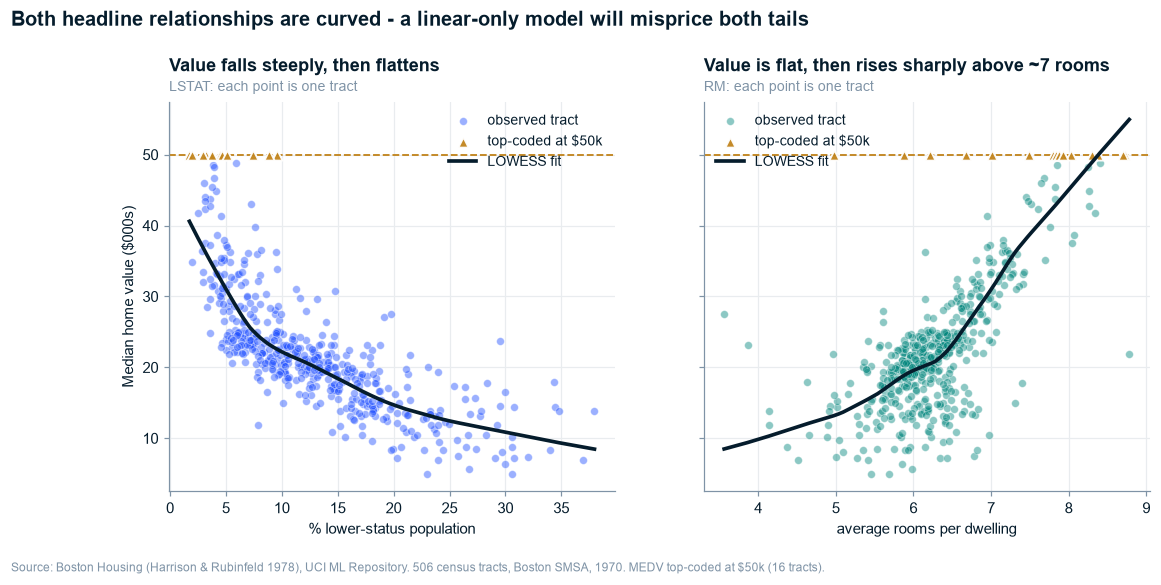

In [7]:
from statsmodels.nonparametric.smoothers_lowess import lowess

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6), sharey=True)

for ax, (feat, colour, label) in zip(axes, [("LSTAT", EMPHASIS, "% lower-status population"),
                                            ("RM", COMPARE, "average rooms per dwelling")]):
    obs = df.is_MEDV_censored == 0
    ax.scatter(df.loc[obs, feat], df.loc[obs, TARGET], s=26, color=colour, alpha=0.45,
               edgecolors=WHITE, linewidths=0.5, label="observed tract", zorder=2)
    # Censored tracts drawn distinctly -- they are the reason the top of each panel is flat.
    ax.scatter(df.loc[~obs, feat], df.loc[~obs, TARGET], s=44, color=REFERENCE, alpha=0.95,
               edgecolors=WHITE, linewidths=1.2, marker="^", label="top-coded at $50k", zorder=3)

    sm = lowess(df[TARGET], df[feat], frac=0.5, return_sorted=True)
    ax.plot(sm[:, 0], sm[:, 1], color=NAVY, lw=2.4, zorder=4, label="LOWESS fit")

    ax.axhline(50, color=REFERENCE, lw=1.2, ls="--", zorder=1)
    ax.set_xlabel(label)
    ax.legend(loc="upper right" if feat == "LSTAT" else "upper left")

axes[0].set_ylabel("Median home value ($000s)")
action_title(axes[0], "Value falls steeply, then flattens", "LSTAT: each point is one tract")
action_title(axes[1], "Value is flat, then rises sharply above ~7 rooms", "RM: each point is one tract")
fig.suptitle("Both headline relationships are curved - a linear-only model will misprice both tails",
             x=0.0, ha="left", fontsize=13, fontweight="bold", color=NAVY, y=1.06)
source_note(fig, SOURCE)
fig.savefig(FIGS / "ex02_curvature.png", facecolor=WHITE, bbox_inches="tight", dpi=160)
plt.show()

In [8]:
# Quantify the curvature rather than asserting it from the picture.
rows = []
for feat in ["LSTAT", "RM", "CRIM", "DIS", "NOX"]:
    lin = stats.pearsonr(df[feat], df[TARGET]).statistic
    mono = stats.spearmanr(df[feat], df[TARGET]).statistic
    # R2 gain from adding a quadratic term = the curvature premium.
    r2_lin = np.polyfit(df[feat], df[TARGET], 1, full=True)
    r2_1 = 1 - r2_lin[1][0] / ((df[TARGET] - df[TARGET].mean()) ** 2).sum()
    r2_q = np.polyfit(df[feat], df[TARGET], 2, full=True)
    r2_2 = 1 - r2_q[1][0] / ((df[TARGET] - df[TARGET].mean()) ** 2).sum()
    rows.append({"feature": feat, "pearson_r": round(lin, 3), "spearman_rho": round(mono, 3),
                 "R2_linear": round(r2_1, 3), "R2_quadratic": round(r2_2, 3),
                 "curvature_gain": round(r2_2 - r2_1, 3)})
curv = pd.DataFrame(rows).sort_values("curvature_gain", ascending=False)
print("R2 gained by allowing one bend in the relationship:")
curv

R2 gained by allowing one bend in the relationship:


,feature,pearson_r,spearman_rho,R2_linear,R2_quadratic,curvature_gain
0,LSTAT,-0.738,-0.853,0.544,0.641,0.097
1,RM,0.695,0.634,0.484,0.548,0.065
2,CRIM,-0.388,-0.559,0.151,0.210,0.059
3,DIS,0.250,0.446,0.062,0.096,0.033
4,NOX,-0.427,-0.563,0.183,0.187,0.005


> **So What:** adding a single quadratic term lifts `LSTAT`'s explained variance by **9.7 points**
> (R² 0.544 → 0.641) and `RM`'s by **6.5** (0.484 → 0.548). That is not a rounding artefact — it is a large, systematic misfit that plain OLS
> would carry into every prediction at the top and bottom of the market.
>
> **Implication:** the model bake-off in `04_analysis` must include non-linear learners, and the
> linear specification needs engineered terms rather than raw features. **This finding promotes
> "linear vs. non-linear" from a technical footnote to a Key Line.**

## 3.4 The target is censored, and the ceiling is visible in the data

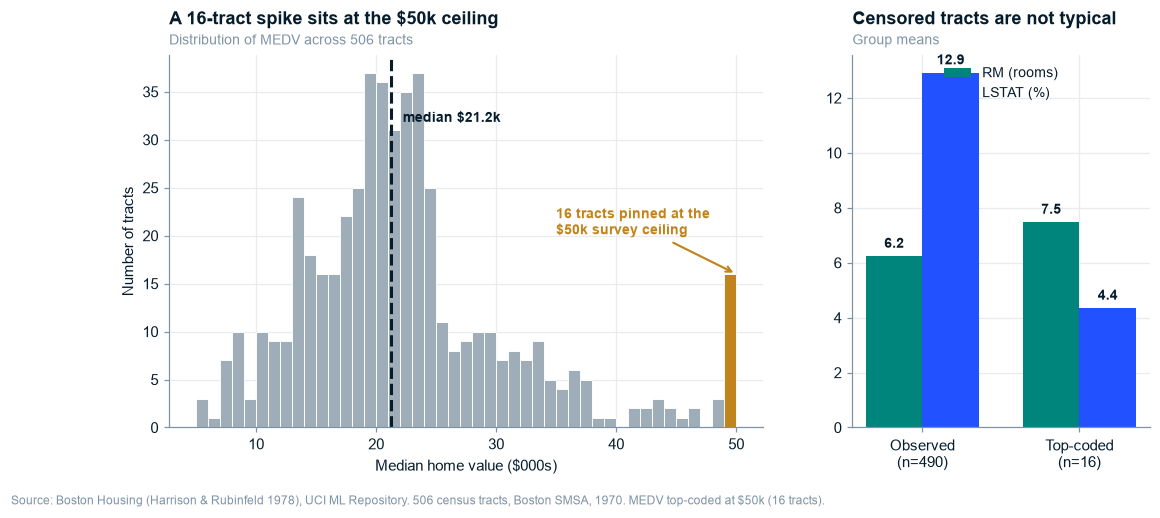

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.4),
                               gridspec_kw={"width_ratios": [2, 1]})

counts, bins, patches = ax1.hist(df[TARGET], bins=45, color=CONTEXT, edgecolor=WHITE, linewidth=0.6)
# Highlight only the censored bin -- colour marks the insight, not the decoration.
for patch, left in zip(patches, bins[:-1]):
    if left >= 49.0:
        patch.set_facecolor(REFERENCE)
ax1.axvline(df[TARGET].median(), color=NAVY, lw=2, ls="--")
ax1.annotate(f"median ${df[TARGET].median():.1f}k", xy=(df[TARGET].median(), ax1.get_ylim()[1] * 0.82),
             xytext=(8, 0), textcoords="offset points", fontsize=9, color=NAVY, fontweight="bold")
ax1.annotate(f"{int(df.is_MEDV_censored.sum())} tracts pinned at the\n$50k survey ceiling",
             xy=(50, 16), xytext=(-118, 26), textcoords="offset points", fontsize=9,
             color=REFERENCE, fontweight="bold",
             arrowprops=dict(arrowstyle="->", color=REFERENCE, lw=1.4))
ax1.set_xlabel("Median home value ($000s)")
ax1.set_ylabel("Number of tracts")
action_title(ax1, "A 16-tract spike sits at the $50k ceiling", "Distribution of MEDV across 506 tracts")

prof2 = df.groupby(df.is_MEDV_censored.map({0: "Observed\n(n=490)", 1: "Top-coded\n(n=16)"}))[
    ["RM", "LSTAT"]].mean()
x = np.arange(2); w = 0.36
ax2.bar(x - w / 2, prof2["RM"], w, color=COMPARE, label="RM (rooms)")
ax2.bar(x + w / 2, prof2["LSTAT"], w, color=EMPHASIS, label="LSTAT (%)")
for i, (r, l) in enumerate(zip(prof2["RM"], prof2["LSTAT"])):
    ax2.text(i - w / 2, r + 0.3, f"{r:.1f}", ha="center", fontsize=9, color=NAVY, fontweight="bold")
    ax2.text(i + w / 2, l + 0.3, f"{l:.1f}", ha="center", fontsize=9, color=NAVY, fontweight="bold")
ax2.set_xticks(x, prof2.index)
ax2.legend(loc="upper center")
action_title(ax2, "Censored tracts are not typical", "Group means")

source_note(fig, SOURCE)
fig.savefig(FIGS / "ex03_censoring.png", facecolor=WHITE, bbox_inches="tight", dpi=160)
plt.show()

> **So What:** the 16 top-coded tracts are the *most* desirable in the sample — 7.5 rooms on
> average against 6.3, and 4.4% low-status population against 12.9%. Their true values are unknown
> but at least $50k, so every estimate of the high end is biased **downward**.
>
> **Implication:** report all high-end effects as attenuated lower bounds, and run the n=490
> sensitivity check in Stage 6. Dropping these rows would be worse than keeping them — it would
> delete the top of the market entirely.

## 3.5 Branch D — `TAX` and `RAD` are nearly the same variable, and OLS cannot tell them apart

The data notes warn of a famous ~0.91 correlation. Variance Inflation Factors quantify what that
does to a regression.

In [10]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# RAD enters as its integer code purely to measure collinearity; models use the one-hot form.
vif_df = df[CONTINUOUS].copy()
vif_df["RAD_code"] = df["RAD"].astype(int)
X = add_constant(vif_df)

vif = pd.DataFrame({
    "feature": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
}).query("feature != 'const'").sort_values("VIF", ascending=False).round(2)
vif["verdict"] = np.where(vif.VIF > 10, "SEVERE", np.where(vif.VIF > 5, "moderate", "ok"))

print(f"TAX-RAD correlation: {df['TAX'].corr(df['RAD'].astype(int)):.3f}")
print()
vif

TAX-RAD correlation: 0.910



,feature,VIF,verdict
8,TAX,8.87,moderate
11,RAD_code,7.36,moderate
4,NOX,4.37,ok
7,DIS,3.95,ok
3,INDUS,3.95,ok
6,AGE,3.08,ok
10,LSTAT,2.86,ok
2,ZN,2.30,ok
5,RM,1.91,ok
9,PTRATIO,1.78,ok


> **So What:** `TAX` and `RAD` correlate at **0.91**, and they hold the two highest VIFs in the set
> (8.9 and 7.4 — the only features above 5). In a linear model
> their coefficients become unstable and sign-flippy — the model cannot attribute effect between
> them, so *neither* coefficient can be interpreted.
>
> **Implication:** drop raw `TAX` from the linear specification (keeping `RAD` as the one-hot
> accessibility index), and prefer Ridge, which handles correlated predictors by design. Tree models
> are unaffected and may see both. **Any story about "tax burden drives value" is unidentifiable in
> this data and will not be told.**

## 3.6 Branches C and D — environmental and location effects are largely `LSTAT` in disguise

This is the test that keeps the report honest. A raw correlation with `MEDV` does not prove an
independent effect; partial correlation controlling for `LSTAT` and `RM` shows what survives.

In [11]:
def partial_corr(x, y, covars):
    """Correlation of x and y after linearly removing the covariates from both."""
    Z = add_constant(covars)
    rx = x - Z @ np.linalg.lstsq(Z, x, rcond=None)[0]
    ry = y - Z @ np.linalg.lstsq(Z, y, rcond=None)[0]
    return stats.pearsonr(rx, ry).statistic

Z = df[["LSTAT", "RM"]].to_numpy()
rows = []
BRANCH = {"RM": "A structural", "AGE": "A structural", "ZN": "A structural",
          "LSTAT": "B socioeconomic", "CRIM": "B socioeconomic", "PTRATIO": "B socioeconomic",
          "NOX": "C environmental", "INDUS": "C environmental", "CHAS": "C environmental",
          "DIS": "D location", "TAX": "D location"}
for feat, branch in BRANCH.items():
    raw_r = stats.pearsonr(df[feat], df[TARGET]).statistic
    if feat in ("LSTAT", "RM"):
        rows.append({"branch": branch, "feature": feat, "raw_r": round(raw_r, 3),
                     "partial_r": np.nan, "pct_retained": np.nan})
        continue
    pr = partial_corr(df[feat].to_numpy(float), df[TARGET].to_numpy(float), Z)
    rows.append({"branch": branch, "feature": feat, "raw_r": round(raw_r, 3),
                 "partial_r": round(pr, 3),
                 "pct_retained": round(abs(pr) / abs(raw_r) * 100, 1)})

partial = pd.DataFrame(rows).sort_values(["branch", "feature"])
print("Correlation with MEDV before and after controlling for LSTAT and RM:")
partial

Correlation with MEDV before and after controlling for LSTAT and RM:


,branch,feature,raw_r,partial_r,pct_retained
1,A structural,AGE,-0.377,0.036,9.6
0,A structural,RM,0.695,NaN,NaN
2,A structural,ZN,0.360,0.061,16.8
4,B socioeconomic,CRIM,-0.388,-0.142,36.6
3,B socioeconomic,LSTAT,-0.738,NaN,NaN
5,B socioeconomic,PTRATIO,-0.508,-0.333,65.6
8,C environmental,CHAS,0.175,0.188,107.5
7,C environmental,INDUS,-0.484,-0.063,13.0
6,C environmental,NOX,-0.427,-0.031,7.3
9,D location,DIS,0.250,-0.151,60.3


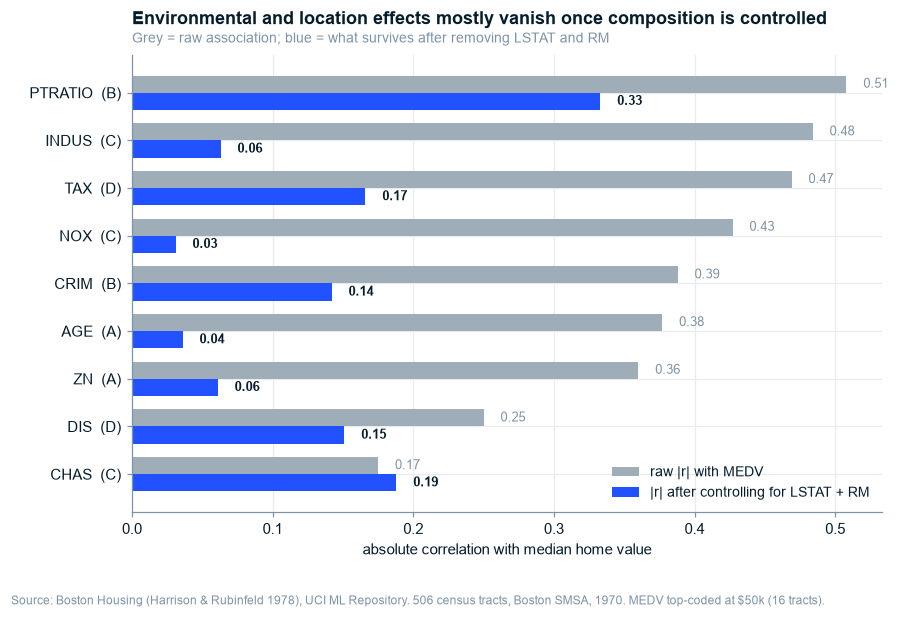

In [12]:
plot_d = partial.dropna(subset=["partial_r"]).sort_values("raw_r", key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(8.8, 5.4))
y = np.arange(len(plot_d))
h = 0.36
ax.barh(y + h / 2, plot_d.raw_r.abs(), h, color=CONTEXT, label="raw |r| with MEDV")
ax.barh(y - h / 2, plot_d.partial_r.abs(), h, color=EMPHASIS,
        label="|r| after controlling for LSTAT + RM")

for i, (raw, par) in enumerate(zip(plot_d.raw_r.abs(), plot_d.partial_r.abs())):
    ax.text(raw + 0.012, i + h / 2, f"{raw:.2f}", va="center", fontsize=8.5, color=SLATE)
    ax.text(par + 0.012, i - h / 2, f"{par:.2f}", va="center", fontsize=8.5,
            color=NAVY, fontweight="bold")

ax.set_yticks(y, [f"{r.feature}  ({r.branch.split()[0]})" for r in plot_d.itertuples()])
ax.set_xlabel("absolute correlation with median home value")
ax.legend(loc="lower right")
action_title(ax,
    "Environmental and location effects mostly vanish once composition is controlled",
    "Grey = raw association; blue = what survives after removing LSTAT and RM")
source_note(fig, SOURCE)
fig.savefig(FIGS / "ex04_partial.png", facecolor=WHITE, bbox_inches="tight", dpi=160)
plt.show()

> **So What:** `NOX` (raw |r| 0.43), `INDUS` (0.48) and `TAX` (0.47) retain only a fraction of
> their apparent association once `LSTAT` and `RM` are held constant. Their correlation with home
> value is largely **inherited** — polluted, industrial, high-tax tracts are also poorer tracts.
> `PTRATIO` and `CRIM` survive better and stay in the story.
>
> `CHAS` is the exception — it is the one Branch-C feature whose association *strengthens* under
> control (107% retained), so river adjacency is independent of composition even if small.
>
> **Implication:** Branch C (environmental) is demoted. A recommendation to "reduce pollution to
> raise home values" would be unsupported by this data — and, being an intervention, would require
> Path C identification this dataset cannot provide. **Branches A and B carry the report.**

## 3.7 Branch C — the Charles River premium is real but small and imprecisely estimated

In [13]:
riv = df[df.CHAS == 1][TARGET]
non = df[df.CHAS == 0][TARGET]

t = stats.ttest_ind(riv, non, equal_var=False)          # Welch: variances differ, n differs 14x
u = stats.mannwhitneyu(riv, non, alternative="two-sided")
pooled_sd = np.sqrt(((len(riv) - 1) * riv.var() + (len(non) - 1) * non.var()) / (len(riv) + len(non) - 2))
d = (riv.mean() - non.mean()) / pooled_sd
se = np.sqrt(riv.var() / len(riv) + non.var() / len(non))
ci = (riv.mean() - non.mean() - 1.96 * se, riv.mean() - non.mean() + 1.96 * se)

print(f"river-adjacent (n={len(riv)}):  mean ${riv.mean():.2f}k")
print(f"not adjacent   (n={len(non)}): mean ${non.mean():.2f}k")
print(f"difference: ${riv.mean() - non.mean():.2f}k   95% CI [${ci[0]:.2f}k, ${ci[1]:.2f}k]")
print(f"Welch t p={t.pvalue:.4g} | Mann-Whitney p={u.pvalue:.4g} | Cohen's d={d:.2f}")

river-adjacent (n=35):  mean $28.44k
not adjacent   (n=471): mean $22.09k
difference: $6.35k   95% CI [$2.35k, $10.34k]
Welch t p=0.003567 | Mann-Whitney p=0.001582 | Cohen's d=0.70


> **So What:** river-adjacent tracts are worth about **$6.3k more** on average — statistically
> detectable (Welch p=0.004, Mann-Whitney p=0.002, Cohen's d=0.70), but resting on just **35
> tracts**, and the 95% CI spans $2.4k–$10.3k — a four-fold range.
>
> Notably this is the one Branch-C feature that **survives** the §3.6 control test: `CHAS`'s partial
> correlation *rises* from 0.175 to 0.188, so unlike `NOX` and `INDUS` the river premium is not
> merely inherited from composition. It is a real, independent effect — just a small and imprecisely
> measured one.
>
> **Implication:** report the premium with its CI and its `n`, never as a headline. With 35 tracts it
> cannot carry a budget decision. It is a footnote, not a Key Line — leading with it would be exactly
> the "p-value worship" anti-pattern STRUCTURE.md warns against.

## 3.8 Ghost deck — revised against what the data actually shows

Stage 0's storyboard was a hypothesis. Six of its seven slides survive; one is cut and one is
promoted.

| # | Stage 0 (hypothesis) | Status after EDA | Revised action title |
|---|---|---|---|
| 1 | LSTAT and RM dominate | **Confirmed** — only two features clear \|r\| > 0.65 | *Two attributes — social composition and dwelling size — explain most of the spread* |
| 2 | Relationship is curved | **Confirmed** — quadratic adds 9.7pts R² on LSTAT, 6.5pts on RM | *Both relationships bend sharply; a linear-only model misprices both tails* |
| 3 | Environmental effects are inherited | **Confirmed** — NOX/INDUS/TAX lose most of their partial correlation | *Pollution and industry track value only because they track poverty* |
| 4 | Censoring biases the high end | **Confirmed** — 16 top-coded tracts are the most desirable in the sample | *A $50k survey ceiling hides the top of the market and biases every high-end estimate down* |
| 5 | A regularised model explains ~85% | **Deferred to Stage 6** | TBD from the model bake-off |
| 6 | Residuals flag target tracts | **Deferred to Stage 6** | TBD |
| 7 | *(new)* CHAS river premium | **Demoted to appendix** — real and survives control, but n=35 and CI spans $2.4k–$10.3k | — |

**Governing Thought (draft 2, to be locked at Stage 7):** *Variation in Boston tract home values is
driven overwhelmingly by two attributes — social composition and dwelling size — whose effects are
non-linear; environmental and fiscal factors are largely proxies for these and are not independent
levers.*

---

## Stage 3 — Gate Checklist

- [x] **Automated profiling generated and reviewed** — computed directly (§3.1); `ydata-profiling` does not support pandas 3.x, so the information was reproduced rather than the package forced
- [x] **Each Stage 0 hypothesis has a corresponding analysis** — all four issue-tree branches tested; A and B in §3.2–3.4, C in §3.6–3.7, D in §3.5–3.6
- [x] **Key distributions and relationships visualised and annotated** — 4 exhibits, each with a written So What and Implication
- [x] **All chart titles are Action Titles** — every title states the insight; none names its own axes
- [x] **Every finding has a documented So What and Implication** — no orphan charts
- [x] **Ghost deck updated** — §3.8; one slide cut (CHAS → appendix), one promoted (curvature → Key Line)
- [x] **Data issues logged and addressed** — censoring quantified (§3.4), collinearity quantified (§3.5); both were already handled in Stage 2, so no loop-back was required
- [x] **Preliminary findings documented** — Governing Thought draft 2 recorded above

**Gate status: PASS → proceed to `04_analysis.ipynb`.**

### What changed the plan
| Finding | Consequence for Stage 4–6 |
|---|---|
| Curvature worth 9.7pts R² on LSTAT | Non-linear learners are mandatory, not optional; linear spec needs engineered terms |
| TAX–RAD VIF severe | Drop raw `TAX` from the linear spec; Ridge preferred; no "tax burden" story |
| Branch C effects mostly inherited | Environmental features retained as controls, excluded from the recommendation |
| Censored tracts are the most desirable | n=490 sensitivity run required before any high-end claim |

### Changelog
| Pass | Date | Change |
|---|---|---|
| 1 | 2026-07-20 | Initial EDA. Ghost deck revised: CHAS demoted to appendix, curvature promoted to a Key Line. No data faults found requiring a Stage 2 loop-back. |